# Day 26 — Trend
### #30DayChartChallenge | April 2026

**How the World Powers Itself**  
A streamgraph of global primary energy consumption by source, 1965–2024.
Total energy demand has tripled — and fossil fuels still dominate despite the rise of renewables.

**Data:** Our World in Data — Global Energy Substitution (BP Statistical Review / Energy Institute)  
**Units:** Terawatt-hours (TWh), substituted energy equivalent  
**Author:** Sharfudeen Yasar Arafath

In [1]:
library(ggplot2)
library(ggstream)
library(dplyr)
library(tidyr)
library(showtext)
library(sysfonts)
library(scales)

font_add_google("Outfit", "outfit")
font_add_google("JetBrains Mono", "jetbrains")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 13, repr.plot.height = 8, repr.plot.res = 300)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"


Warning message:
"package 'dplyr' was built under R version 4.5.3"



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Warning message:
"package 'tidyr' was built under R version 4.5.3"


Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
df_raw <- read.csv("../../data/day_26b/owid_energy.csv")

df <- df_raw |>
  filter(entity == "World", year >= 1965) |>
  select(
    year,
    Coal           = coal__twh_substituted_energy,
    Oil            = oil__twh_substituted_energy,
    Gas            = gas__twh_substituted_energy,
    Nuclear        = nuclear__twh_substituted_energy,
    Hydropower     = hydropower__twh_substituted_energy,
    Wind           = wind__twh_substituted_energy,
    Solar          = solar__twh_substituted_energy,
    `Other renewables` = other_renewables__twh_substituted_energy
  ) |>
  pivot_longer(-year, names_to = "source", values_to = "twh") |>
  mutate(
    source = factor(source, levels = c(
      "Coal", "Oil", "Gas",
      "Nuclear", "Hydropower",
      "Wind", "Solar", "Other renewables"
    ))
  )

cat("Rows:", nrow(df), "\n")
cat("2024 total TWh:",
  round(sum(df$twh[df$year == 2024]) / 1e3), "PWh\n")
cat("1965 total TWh:",
  round(sum(df$twh[df$year == 1965]) / 1e3), "PWh\n")

Rows: 480 


2024 total TWh: 174 PWh


1965 total TWh: 43 PWh


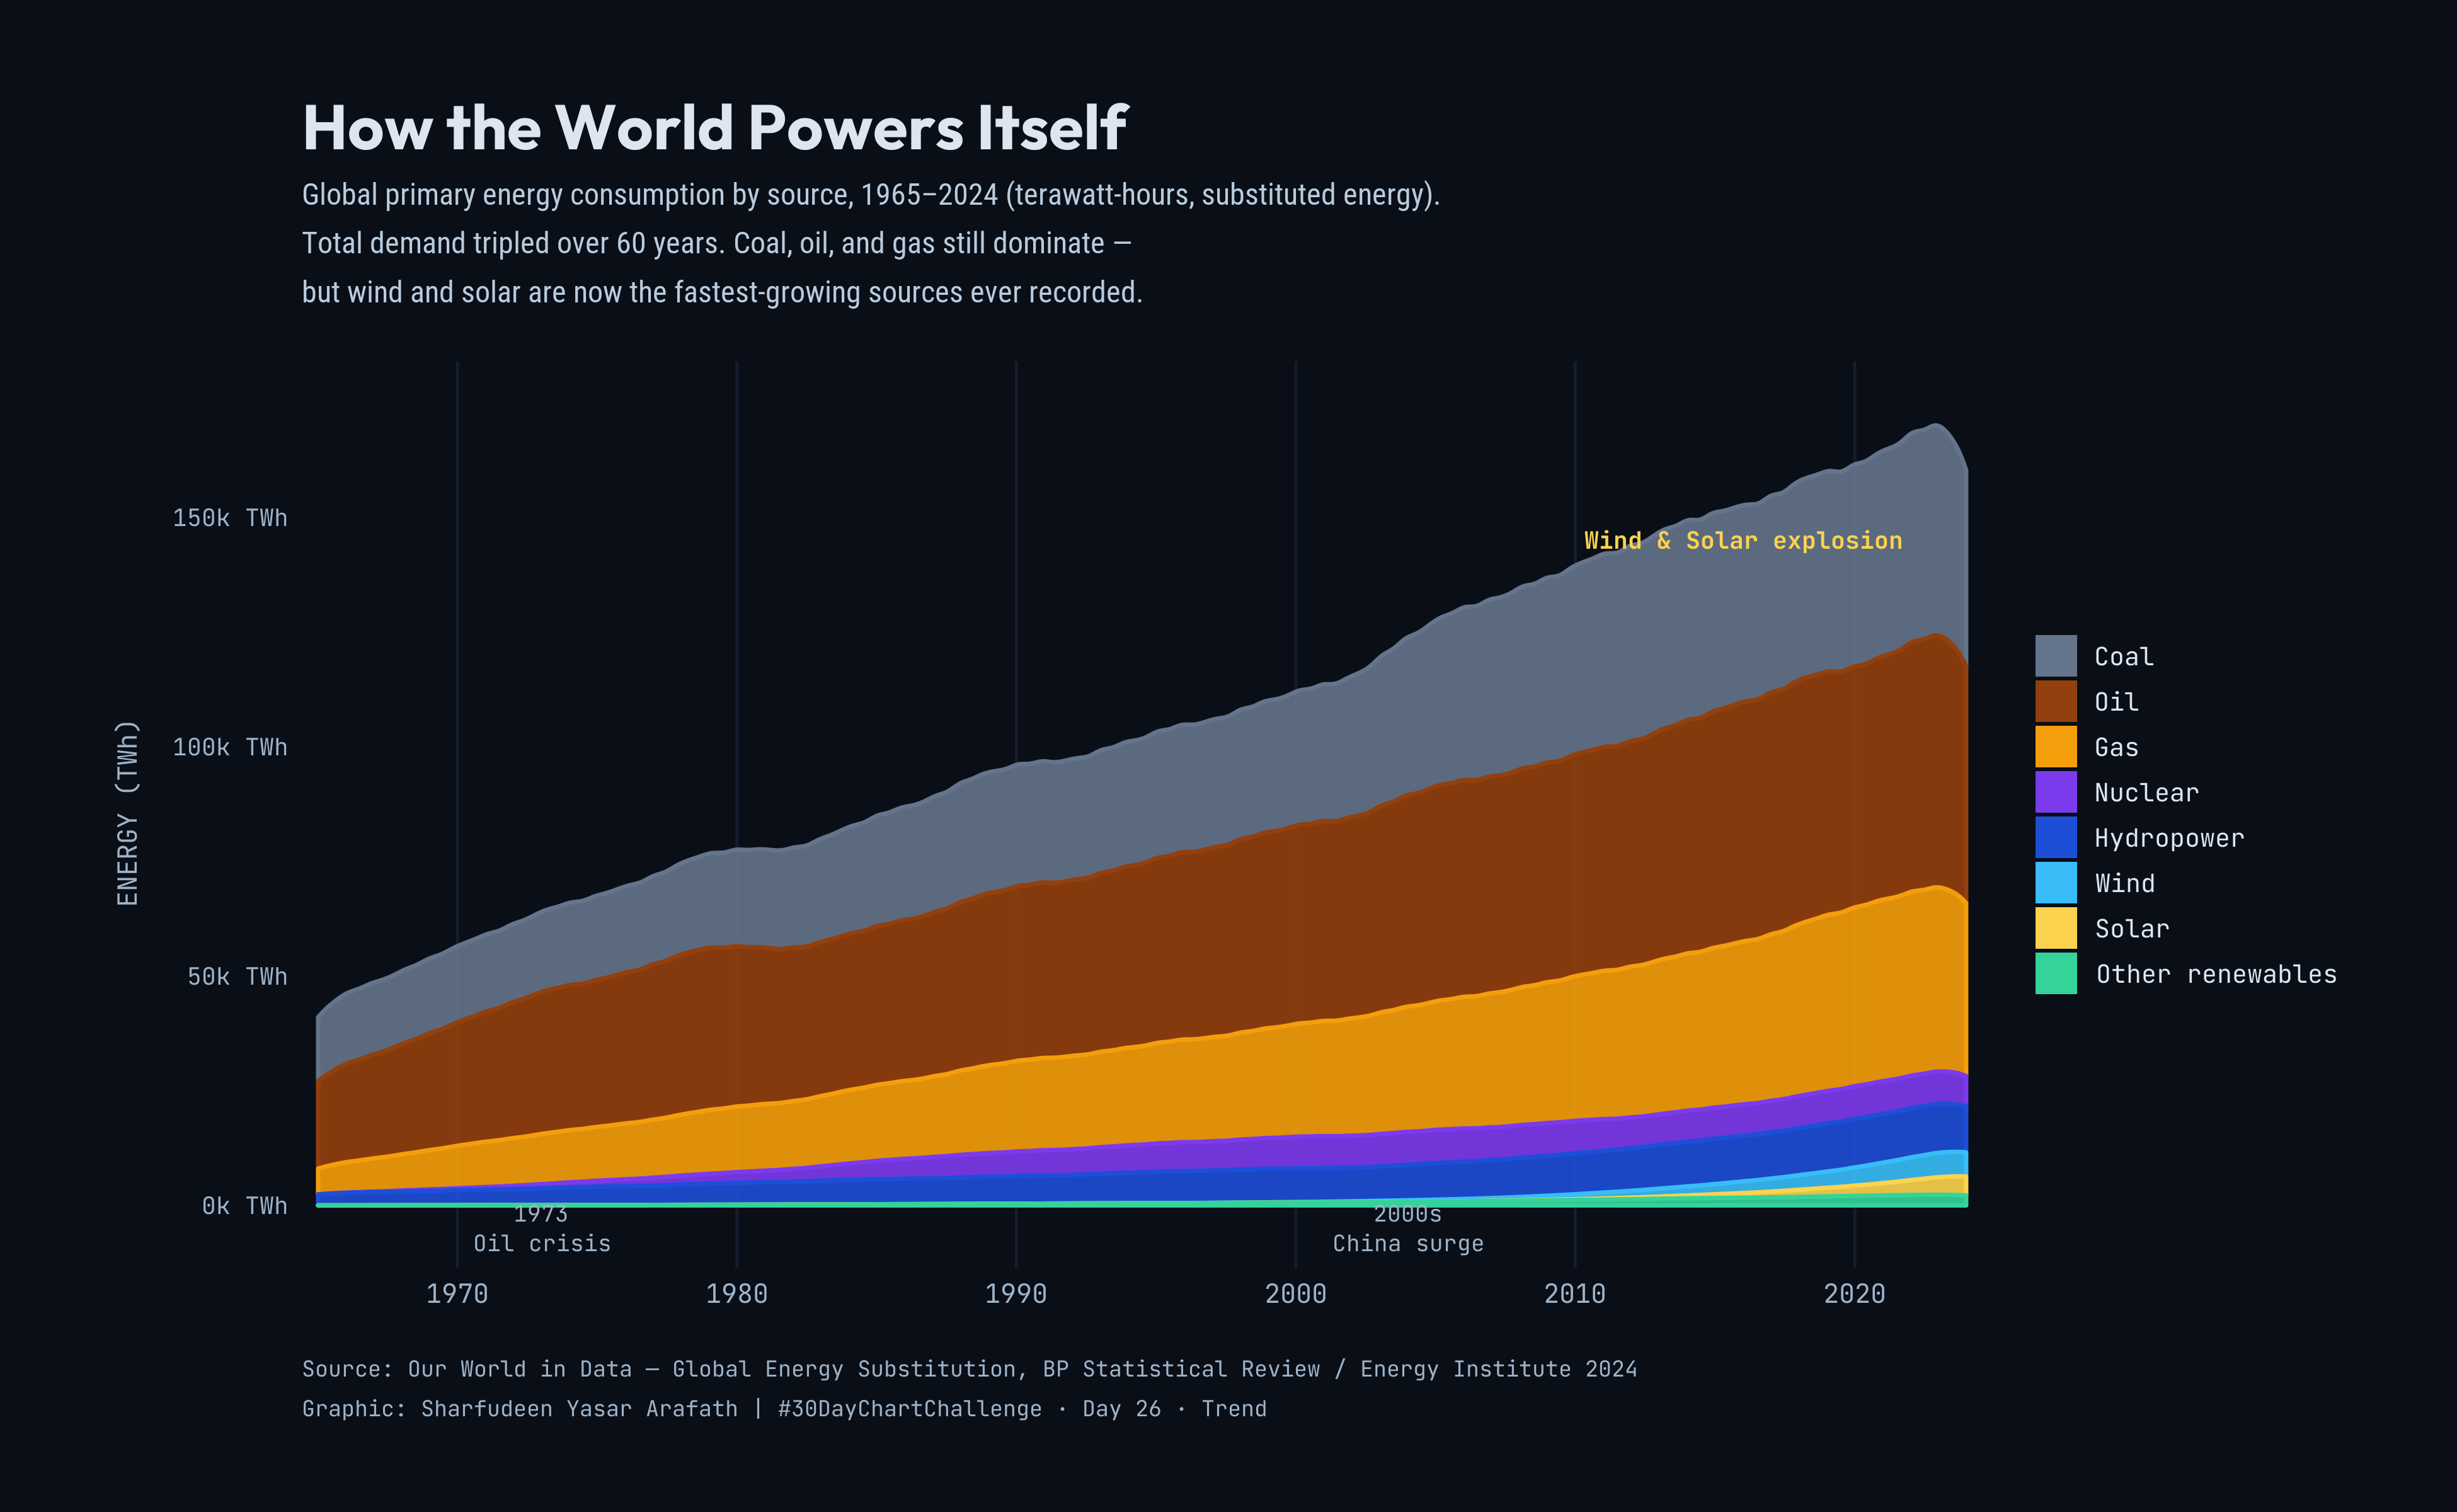

In [3]:
bg_col   <- "#0a0e17"
text_col <- "#dde5f0"
subtext  <- "#9eb3c8"
grid_col <- "#151d2e"

source_colours <- c(
  "Coal"             = "#64748b",
  "Oil"              = "#92400e",
  "Gas"              = "#f59e0b",
  "Nuclear"          = "#7c3aed",
  "Hydropower"       = "#1d4ed8",
  "Wind"             = "#38bdf8",
  "Solar"            = "#fcd34d",
  "Other renewables" = "#34d399"
)

p <- ggplot(df, aes(x = year, y = twh, fill = source, colour = source)) +

  geom_stream(type = "ridge", alpha = 0.9, bw = 0.6) +

  scale_fill_manual(values   = source_colours, name = NULL) +
  scale_colour_manual(values = source_colours, name = NULL, guide = "none") +

  annotate("text", x = 1973, y = -5000, label = "1973\nOil crisis",
           hjust = 0.5, size = 3, colour = subtext,
           family = "jetbrains", lineheight = 1.1) +

  annotate("text", x = 2004, y = -5000, label = "2000s\nChina surge",
           hjust = 0.5, size = 3, colour = subtext,
           family = "jetbrains", lineheight = 1.1) +

  annotate("text", x = 2016, y = 145000, label = "Wind & Solar explosion",
           hjust = 0.5, size = 3.2, colour = "#fcd34d",
           family = "jetbrains", fontface = "bold") +

  scale_x_continuous(
    breaks = seq(1970, 2020, 10),
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  scale_y_continuous(
    labels = function(x) paste0(round(x / 1000), "k TWh"),
    expand = expansion(mult = c(0.05, 0.08))
  ) +

  coord_cartesian(clip = "off") +

  labs(
    title    = "How the World Powers Itself",
    subtitle = paste0(
      "Global primary energy consumption by source, 1965–2024 (terawatt-hours, substituted energy).\n",
      "Total demand tripled over 60 years. Coal, oil, and gas still dominate —\n",
      "but wind and solar are now the fastest-growing sources ever recorded."
    ),
    x       = NULL,
    y       = "ENERGY (TWh)",
    caption = paste0(
      "Source: Our World in Data — Global Energy Substitution, BP Statistical Review / Energy Institute 2024\n",
      "Graphic: Sharfudeen Yasar Arafath | #30DayChartChallenge · Day 26 · Trend"
    )
  ) +

  theme_minimal(base_family = "outfit", base_size = 13) +
  theme(
    plot.background    = element_rect(fill = bg_col, colour = NA),
    panel.background   = element_rect(fill = bg_col, colour = NA),
    panel.grid.major.x = element_line(colour = grid_col, linewidth = 0.4),
    panel.grid.major.y = element_blank(),
    panel.grid.minor   = element_blank(),

    plot.title    = element_text(family = "outfit", face = "bold", size = 24,
                                 colour = text_col, margin = margin(b = 8)),
    plot.subtitle = element_text(family = "roboto_condensed", size = 11.5,
                                 colour = "#b8ccde", lineheight = 1.35, margin = margin(b = 20)),
    plot.caption  = element_text(family = "jetbrains", size = 8.5, colour = subtext,
                                 hjust = 0, lineheight = 1.5, margin = margin(t = 20)),

    axis.text.x  = element_text(family = "jetbrains", size = 10, colour = subtext),
    axis.text.y  = element_text(family = "jetbrains", size = 9,  colour = subtext),
    axis.title.y = element_text(family = "jetbrains", size = 10, colour = subtext,
                                margin = margin(r = 12)),

    legend.background = element_rect(fill = bg_col, colour = NA),
    legend.key        = element_rect(fill = bg_col, colour = NA),
    legend.text       = element_text(family = "jetbrains", size = 9.5, colour = text_col),
    legend.position   = "right",
    legend.spacing.y  = unit(5, "pt"),

    plot.margin = margin(40, 40, 35, 45)
  ) +
  guides(fill = guide_legend(override.aes = list(alpha = 1)))

p

In [4]:
ggsave("../../chart/day_26_trend.png", plot = p,
       width = 13, height = 8, dpi = 300, bg = bg_col)
cat("\u2705 Day 26 Trend streamgraph saved\n")

✅ Day 26 Trend streamgraph saved
